# 📊 SEMAINE 2 : Exploration Approfondie des Données

**Projet:** Détection précoce DT1 - Cameroun  
**Objectifs:**
- Analyser statistiquement les données du dataset DT1
- Étudier les corrélations entre variables
- Visualiser les distributions des biomarqueurs
- Identifier les patterns discriminants DT1 vs Sain
- Détecter et traiter les outliers

**Durée estimée:** 10-12 heures

---

## 🔧 Configuration et Chargement des Données

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # Tests statistiques
from scipy.stats import normaltest, shapiro, kstest  # Tests de normalité
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


In [2]:
# Charger le dataset nettoyé
df = pd.read_csv('../2_DONNEES/processed/dataset_clean.csv')

print("📂 Dataset chargé:")
print(f"   Dimensions: {df.shape[0]} patients × {df.shape[1]} colonnes")
print(f"\nAperçu des premières lignes:")
display(df.head())

print(f"\nTypes de données:")
print(df.dtypes)

📂 Dataset chargé:
   Dimensions: 1000 patients × 18 colonnes

Aperçu des premières lignes:


,ID_patient,age,sexe,IMC,glycemie_jeun,HbA1c,antecedents_familiaux,ANP32A_IT1,ESCO2,NBPF1,diagnostic,sexe_encoded,region_Bamenda,region_Douala,region_Garoua,region_Maroua,region_Ngaoundéré,region_Yaoundé
0,PAT0522,41.0,F,26.53,4.33,5.02,0.0,1.048,1.000,1.047,0,1,False,False,False,False,False,True
1,PAT0738,46.0,F,28.21,4.77,5.90,0.0,2.327,2.247,3.053,0,1,False,False,False,False,False,True
2,PAT0741,12.0,M,20.63,5.55,5.18,0.0,0.727,1.000,1.097,0,0,False,True,False,False,False,False
3,PAT0661,28.0,F,30.05,6.11,5.16,0.0,0.972,1.271,1.165,0,1,False,False,True,False,False,False
4,PAT0412,21.0,M,31.74,3.73,5.88,0.0,0.652,1.424,1.999,0,0,False,False,False,False,False,True



Types de données:
ID_patient                object
age                      float64
sexe                      object
IMC                      float64
glycemie_jeun            float64
HbA1c                    float64
antecedents_familiaux    float64
ANP32A_IT1               float64
ESCO2                    float64
NBPF1                    float64
diagnostic                 int64
sexe_encoded               int64
region_Bamenda              bool
region_Douala               bool
region_Garoua               bool
region_Maroua               bool
region_Ngaoundéré           bool
region_Yaoundé              bool
dtype: object


## 📈 Partie 1 : Analyse Statistique Descriptive

Nous allons calculer les statistiques descriptives pour chaque variable et les comparer entre les groupes DT1 et Sain.

In [3]:
# === STATISTIQUES GLOBALES ===

# Statistiques descriptives pour toutes les variables numériques
print("📊 STATISTIQUES DESCRIPTIVES GLOBALES\n")
print(df.describe().round(2))

# Focus sur les variables clés
variables_cles = ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 'ANP32A_IT1', 'ESCO2', 'NBPF1']

print("\n📌 Statistiques des variables clés:")
for var in variables_cles:
    print(f"\n{var.upper()}:")
    print(f"   Moyenne: {df[var].mean():.2f}")
    print(f"   Médiane: {df[var].median():.2f}")
    print(f"   Écart-type: {df[var].std():.2f}")
    print(f"   Min-Max: [{df[var].min():.2f}, {df[var].max():.2f}]")
    print(f"   IQR: {df[var].quantile(0.75) - df[var].quantile(0.25):.2f}")

📊 STATISTIQUES DESCRIPTIVES GLOBALES

           age      IMC  glycemie_jeun    HbA1c  antecedents_familiaux  \
count  1000.00  1000.00        1000.00  1000.00                1000.00   
mean     32.26    24.27           6.31     6.19                   0.23   
std      11.77     4.55           2.72     2.04                   0.42   
min       5.00    15.00           3.00     4.00                   0.00   
25%      24.00    21.01           4.62     4.98                   0.00   
50%      31.00    23.94           5.32     5.41                   0.00   
75%      40.00    27.11           6.57     6.16                   0.00   
max      70.00    40.00          18.25    14.00                   1.00   

       ANP32A_IT1    ESCO2    NBPF1  diagnostic  sexe_encoded  
count     1000.00  1000.00  1000.00     1000.00       1000.00  
mean         2.52     3.02     2.16        0.25          0.52  
std          1.76     2.03     1.40        0.43          0.50  
min          0.50     1.00     0.80    

📊 COMPARAISON DT1 vs SAIN

              age                  IMC              glycemie_jeun        \
             mean    std median   mean   std median          mean   std   
diagnostic                                                                
0           34.84  11.76   35.0  25.15  4.65  25.03          4.98  0.81   
1           24.50   7.71   25.0  21.62  2.90  21.53         10.30  2.53   

                  HbA1c  ...        ANP32A_IT1              ESCO2        \
           median  mean  ... median       mean   std median  mean   std   
diagnostic               ...                                              
0            4.97  5.21  ...   5.21       1.99  1.28   1.70  2.27  1.23   
1           10.25  9.16  ...   9.16       4.12  2.01   3.61  5.24  2.32   

                  NBPF1               
           median  mean   std median  
diagnostic                            
0            1.98  1.81  1.17   1.48  
1            4.86  3.23  1.50   2.95  

[2 rows x 21 columns]


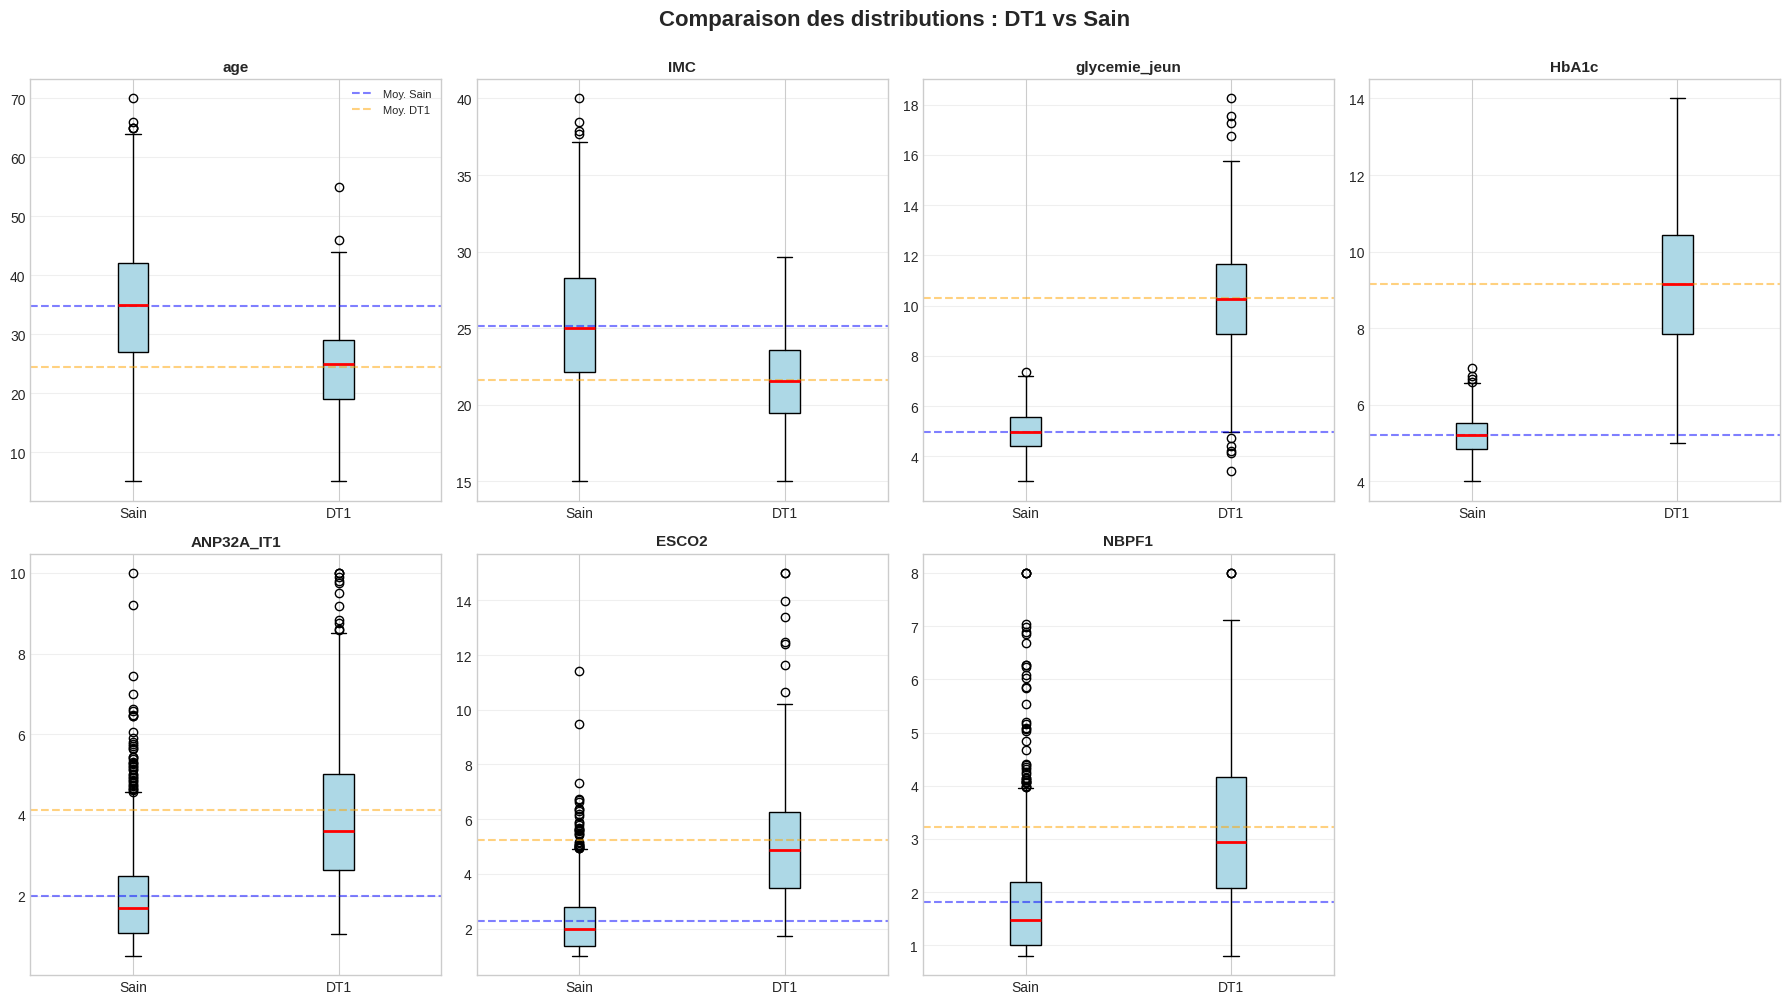


💡 Interprétation:
   - Les boîtes montrent la distribution (Q1-Q3)
   - La ligne rouge dans la boîte = médiane
   - Les lignes pointillées = moyennes
   - Les points isolés = outliers potentiels


In [4]:
# === STATISTIQUES PAR GROUPE (DT1 vs Sain) ===

print("📊 COMPARAISON DT1 vs SAIN\n")

# Créer un DataFrame comparatif
comparaison = df.groupby('diagnostic')[variables_cles].agg(['mean', 'std', 'median'])
print(comparaison.round(2))

# Visualisation comparative
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_cles): #donne un index ET la valeur 
    # Séparer les données par groupe
    sain = df[df['diagnostic'] == 0][var]#Filtre pour obtenir UNIQUEMENT les valeurs de var pour les personnes saines.
    dt1 = df[df['diagnostic'] == 1][var]
    
    # Boxplot comparatif
    axes[i].boxplot([sain, dt1], labels=['Sain', 'DT1'],
                     patch_artist=True,                  #Permet de colorier les boîtes
                     boxprops=dict(facecolor='lightblue'),  #Boîtes en bleu clair
                     medianprops=dict(color='red', linewidth=2)) #Ligne médiane rouge épaisse
    axes[i].set_title(f'{var}', fontweight='bold', fontsize=11)
    axes[i].grid(axis='y', alpha=0.3)       #alpha=0.3 : Transparence à 30% (discret)
    
    # Ajouter les moyennes
    axes[i].axhline(sain.mean(), color='blue', linestyle='--', alpha=0.5, label='Moy. Sain')
    axes[i].axhline(dt1.mean(), color='orange', linestyle='--', alpha=0.5, label='Moy. DT1')
    
    if i == 0:
        axes[i].legend(fontsize=8)

# Supprimer le dernier subplot vide
axes[7].axis('off') #Cache le 8e graphique (qui est vide, car on n'a que 7 variables).

plt.suptitle('Comparaison des distributions : DT1 vs Sain', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n💡 Interprétation:")
print("   - Les boîtes montrent la distribution (Q1-Q3)")
print("   - La ligne rouge dans la boîte = médiane")
print("   - Les lignes pointillées = moyennes")
print("   - Les points isolés = outliers potentiels")

## 🔬 Partie 2 : Tests Statistiques

Nous allons effectuer des tests statistiques pour déterminer si les différences entre DT1 et Sain sont significatives.

In [5]:
# === TEST DE NORMALITÉ ===

print("🔬 TESTS DE NORMALITÉ (Shapiro-Wilk)\n")
print("Hypothèse nulle (H0): Les données suivent une distribution normale")
print("Si p-value < 0.05 → Rejeter H0 (distribution NON normale)\n")

resultats_normalite = []

for var in variables_cles:
    # Test de Shapiro-Wilk (échantillon aléatoire de 500 pour la rapidité)
    echantillon = df[var].sample(min(500, len(df)), random_state=42)
    stat, p_value = shapiro(echantillon)
    
    est_normal = "✅ Normale" if p_value > 0.05 else "❌ Non normale"
    resultats_normalite.append({'Variable': var, 'p-value': p_value, 'Normalité': est_normal})
    
    print(f"{var:15} : p-value = {p_value:.4f} → {est_normal}")

df_normalite = pd.DataFrame(resultats_normalite)

print("\n💡 Implication:")
print("   - Si normale: utiliser tests paramétriques (t-test)")
print("   - Si non normale: utiliser tests non-paramétriques (Mann-Whitney)")

🔬 TESTS DE NORMALITÉ (Shapiro-Wilk)

Hypothèse nulle (H0): Les données suivent une distribution normale
Si p-value < 0.05 → Rejeter H0 (distribution NON normale)

age             : p-value = 0.0058 → ❌ Non normale
IMC             : p-value = 0.0002 → ❌ Non normale
glycemie_jeun   : p-value = 0.0000 → ❌ Non normale
HbA1c           : p-value = 0.0000 → ❌ Non normale
ANP32A_IT1      : p-value = 0.0000 → ❌ Non normale
ESCO2           : p-value = 0.0000 → ❌ Non normale
NBPF1           : p-value = 0.0000 → ❌ Non normale

💡 Implication:
   - Si normale: utiliser tests paramétriques (t-test)
   - Si non normale: utiliser tests non-paramétriques (Mann-Whitney)


In [6]:
# === TESTS DE DIFFÉRENCE ENTRE GROUPES ===

print("🔬 TESTS DE COMPARAISON DT1 vs SAIN\n")
print("Test utilisé: Mann-Whitney U (non-paramétrique)")
print("Hypothèse nulle (H0): Pas de différence entre les deux groupes")
print("Si p-value < 0.05 → Différence statistiquement significative\n")

resultats_tests = []

for var in variables_cles:
    # Séparer les données
    sain = df[df['diagnostic'] == 0][var]
    dt1 = df[df['diagnostic'] == 1][var]
    
    # Test de Mann-Whitney U
    stat, p_value = stats.mannwhitneyu(sain, dt1, alternative='two-sided')
    
    # Calculer l'effet size (différence des médianes normalisée)
    effect_size = (dt1.median() - sain.median()) / df[var].std() # Mesure **l'ampleur** de la différence (pas juste si elle existe).
    
    # Interpréter la significativité
    if p_value < 0.001:
        significativite = "*** Très significatif"
    elif p_value < 0.01:
        significativite = "** Significatif"
    elif p_value < 0.05:
        significativite = "* Significatif"
    else:
        significativite = "Non significatif"
    
    resultats_tests.append({
        'Variable': var,
        'p-value': p_value,
        'Effect Size': effect_size,
        'Significativité': significativite
    })
    
    print(f"{var:15} : p-value = {p_value:.6f}, Effect size = {effect_size:+.3f} → {significativite}")

df_tests = pd.DataFrame(resultats_tests) # Convertit la liste de dictionnaires en DataFrame pandas.

print("\n💡 Légende Effect Size:")
print("   Petit: |0.2-0.5|, Moyen: |0.5-0.8|, Large: |>0.8|")
print("   Signe positif: valeurs plus élevées chez DT1")

🔬 TESTS DE COMPARAISON DT1 vs SAIN

Test utilisé: Mann-Whitney U (non-paramétrique)
Hypothèse nulle (H0): Pas de différence entre les deux groupes
Si p-value < 0.05 → Différence statistiquement significative

age             : p-value = 0.000000, Effect size = -0.849 → *** Très significatif
IMC             : p-value = 0.000000, Effect size = -0.770 → *** Très significatif
glycemie_jeun   : p-value = 0.000000, Effect size = +1.939 → *** Très significatif
HbA1c           : p-value = 0.000000, Effect size = +1.936 → *** Très significatif
ANP32A_IT1      : p-value = 0.000000, Effect size = +1.086 → *** Très significatif
ESCO2           : p-value = 0.000000, Effect size = +1.419 → *** Très significatif
NBPF1           : p-value = 0.000000, Effect size = +1.050 → *** Très significatif

💡 Légende Effect Size:
   Petit: |0.2-0.5|, Moyen: |0.5-0.8|, Large: |>0.8|
   Signe positif: valeurs plus élevées chez DT1


## 🔗 Partie 3 : Analyse des Corrélations

Étudier les relations entre variables pour comprendre les interdépendances.

🔗 MATRICE DE CORRÉLATION (Pearson)

                age   IMC  glycemie_jeun  HbA1c  ANP32A_IT1  ESCO2  NBPF1  \
age            1.00  0.15          -0.31  -0.31       -0.19  -0.21  -0.13   
IMC            0.15  1.00          -0.27  -0.29       -0.19  -0.21  -0.15   
glycemie_jeun -0.31 -0.27           1.00   0.72        0.40   0.57   0.36   
HbA1c         -0.31 -0.29           0.72   1.00        0.42   0.58   0.38   
ANP32A_IT1    -0.19 -0.19           0.40   0.42        1.00   0.36   0.24   
ESCO2         -0.21 -0.21           0.57   0.58        0.36   1.00   0.28   
NBPF1         -0.13 -0.15           0.36   0.38        0.24   0.28   1.00   
diagnostic    -0.38 -0.34           0.85   0.84        0.52   0.63   0.44   

               diagnostic  
age                 -0.38  
IMC                 -0.34  
glycemie_jeun        0.85  
HbA1c                0.84  
ANP32A_IT1           0.52  
ESCO2                0.63  
NBPF1                0.44  
diagnostic           1.00  


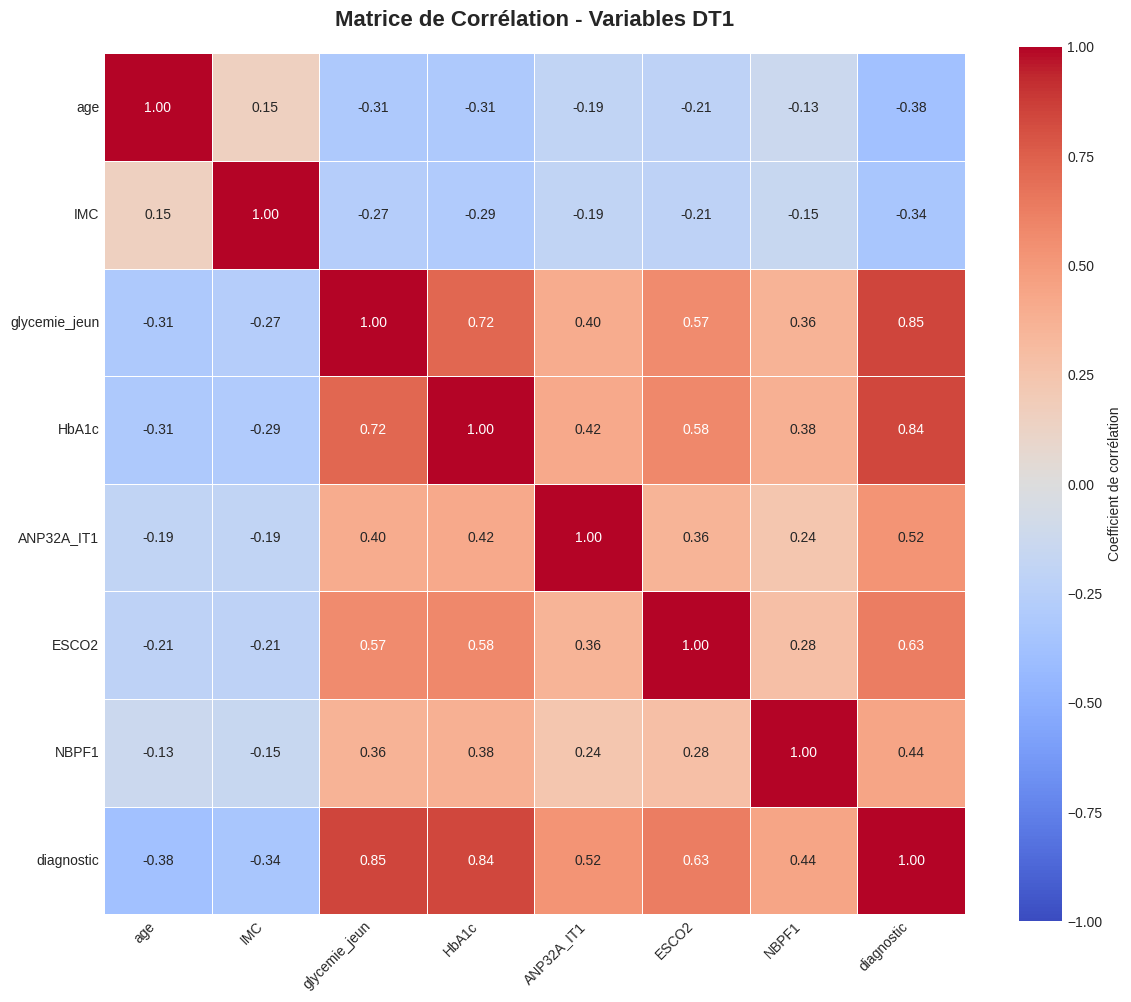


💡 Interprétation:
   Rouge foncé (+1): Corrélation positive parfaite
   Bleu foncé (-1): Corrélation négative parfaite
   Blanc (0): Pas de corrélation
   |r| > 0.7: Forte corrélation
   |r| 0.3-0.7: Corrélation modérée
   |r| < 0.3: Faible corrélation


In [7]:
# === MATRICE DE CORRÉLATION ===

# Calculer la matrice de corrélation (Pearson)
matrice_corr = df[variables_cles + ['diagnostic']].corr() #Calcule toutes les corrélations entre les variables.

print("🔗 MATRICE DE CORRÉLATION (Pearson)\n")
print(matrice_corr.round(2))
    
# Visualisation avec heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matrice_corr,         #Crée une "carte thermique" (heatmap) avec la bibliothèque Seaborn.
            annot=True,           # Afficher les valeurs
            fmt='.2f',            # Format 2 décimales
            cmap='coolwarm',      # Palette de couleurs
            center=0,             # Centrer sur 0
            vmin=-1, vmax=1,      # Échelle -1 à +1
            square=True,          # Cases carrées
            linewidths=0.5,       # Lignes de séparation
            cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Matrice de Corrélation - Variables DT1', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Interprétation:")
print("   Rouge foncé (+1): Corrélation positive parfaite")
print("   Bleu foncé (-1): Corrélation négative parfaite")
print("   Blanc (0): Pas de corrélation")
print("   |r| > 0.7: Forte corrélation")
print("   |r| 0.3-0.7: Corrélation modérée")
print("   |r| < 0.3: Faible corrélation")

🎯 CORRÉLATIONS AVEC LE DIAGNOSTIC DT1

glycemie_jeun    0.847
HbA1c            0.837
ESCO2            0.632
ANP32A_IT1       0.525
NBPF1            0.441
IMC             -0.336
age             -0.380
Name: diagnostic, dtype: float64


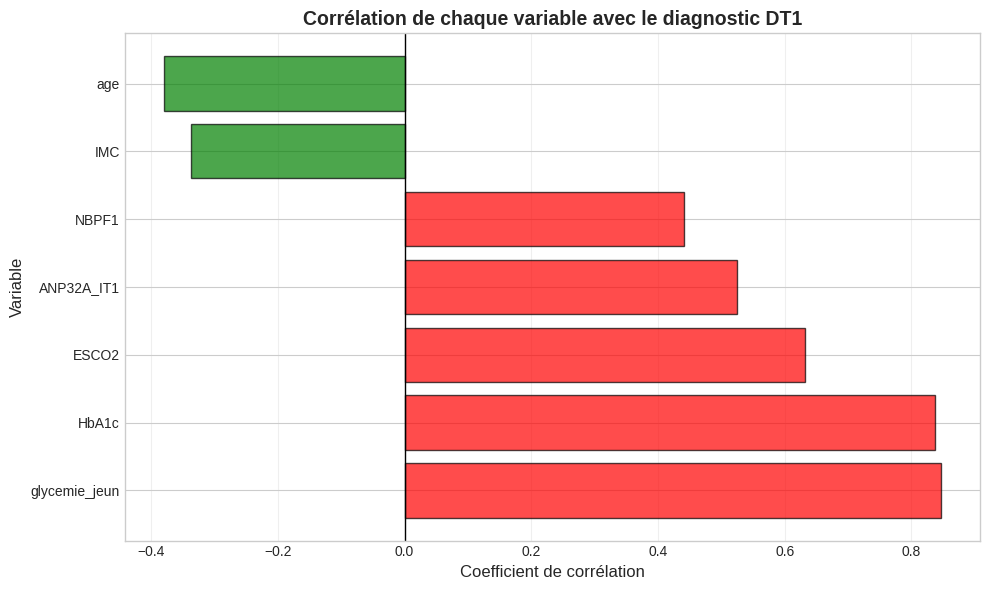


🔍 Variables les plus corrélées avec DT1:
   1. glycemie_jeun: r = 0.847
   2. HbA1c: r = 0.837
   3. ESCO2: r = 0.632


In [8]:
# === CORRÉLATIONS AVEC LE DIAGNOSTIC ===

# Extraire les corrélations avec la variable cible
correlations_diagnostic = matrice_corr['diagnostic'].drop('diagnostic').sort_values(ascending=False)

print("🎯 CORRÉLATIONS AVEC LE DIAGNOSTIC DT1\n")
print(correlations_diagnostic.round(3))

# Visualisation
plt.figure(figsize=(10, 6))
colors = ['green' if x < 0 else 'red' for x in correlations_diagnostic.values]
plt.barh(correlations_diagnostic.index, correlations_diagnostic.values, 
         color=colors, edgecolor='black', alpha=0.7)
plt.xlabel('Coefficient de corrélation', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Corrélation de chaque variable avec le diagnostic DT1', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1) #Pour séparer visuellement les corrélations positives (droite) des négatives (gauche).
plt.grid(axis='x', alpha=0.3) #Ajoute des lignes de grille verticales en transparence.
plt.tight_layout()
plt.show()

print("\n🔍 Variables les plus corrélées avec DT1:")
top_3 = correlations_diagnostic.head(3)
for i, (var, corr) in enumerate(top_3.items(), 1):
    print(f"   {i}. {var}: r = {corr:.3f}")

📊 Création du pairplot (peut prendre 30-60 secondes)...


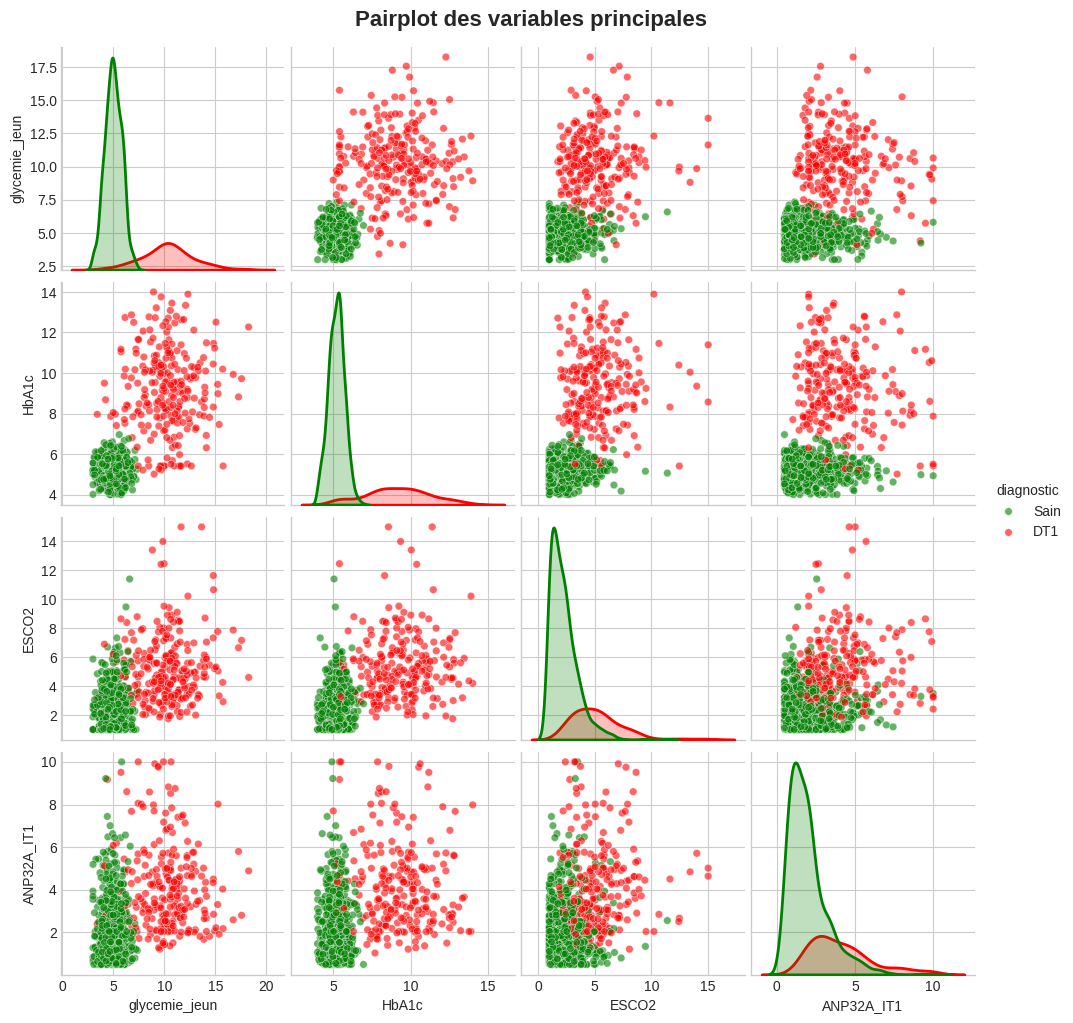


💡 Interprétation du pairplot:
   - Diagonale: Distribution de chaque variable (courbe de densité)
   - Hors diagonale: Relations 2 à 2 entre variables
   - Rechercher des séparations claires vert/rouge (DT1 vs Sain)


In [9]:
# === PAIRPLOT (Nuage de points multiples) ===

print("📊 Création du pairplot (peut prendre 30-60 secondes)...")

# Sélectionner un sous-ensemble de variables pour la lisibilité
variables_pairplot = ['glycemie_jeun', 'HbA1c', 'ESCO2', 'ANP32A_IT1', 'diagnostic']
df_pairplot = df[variables_pairplot].copy() #.copy() : Modification isolée pour ne pas modifier l'original
df_pairplot['diagnostic'] = df_pairplot['diagnostic'].map({0: 'Sain', 1: 'DT1'}) #Traité comme variable catégorielle __ couleur distintes_tres clair

# Créer le pairplot
pairplot = sns.pairplot(df_pairplot, 
                        hue='diagnostic',
                        palette={'Sain': 'green', 'DT1': 'red'},
                        diag_kind='kde',       # Densité sur la diagonale
                        plot_kws={'alpha': 0.6, 's': 30},
                        diag_kws={'linewidth': 2})
pairplot.fig.suptitle('Pairplot des variables principales', 
                      fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n💡 Interprétation du pairplot:")
print("   - Diagonale: Distribution de chaque variable (courbe de densité)")
print("   - Hors diagonale: Relations 2 à 2 entre variables")
print("   - Rechercher des séparations claires vert/rouge (DT1 vs Sain)")

## 🧬 Partie 4 : Analyse des Biomarqueurs

Focus spécifique sur les trois biomarqueurs génétiques : ANP32A-IT1, ESCO2, NBPF1

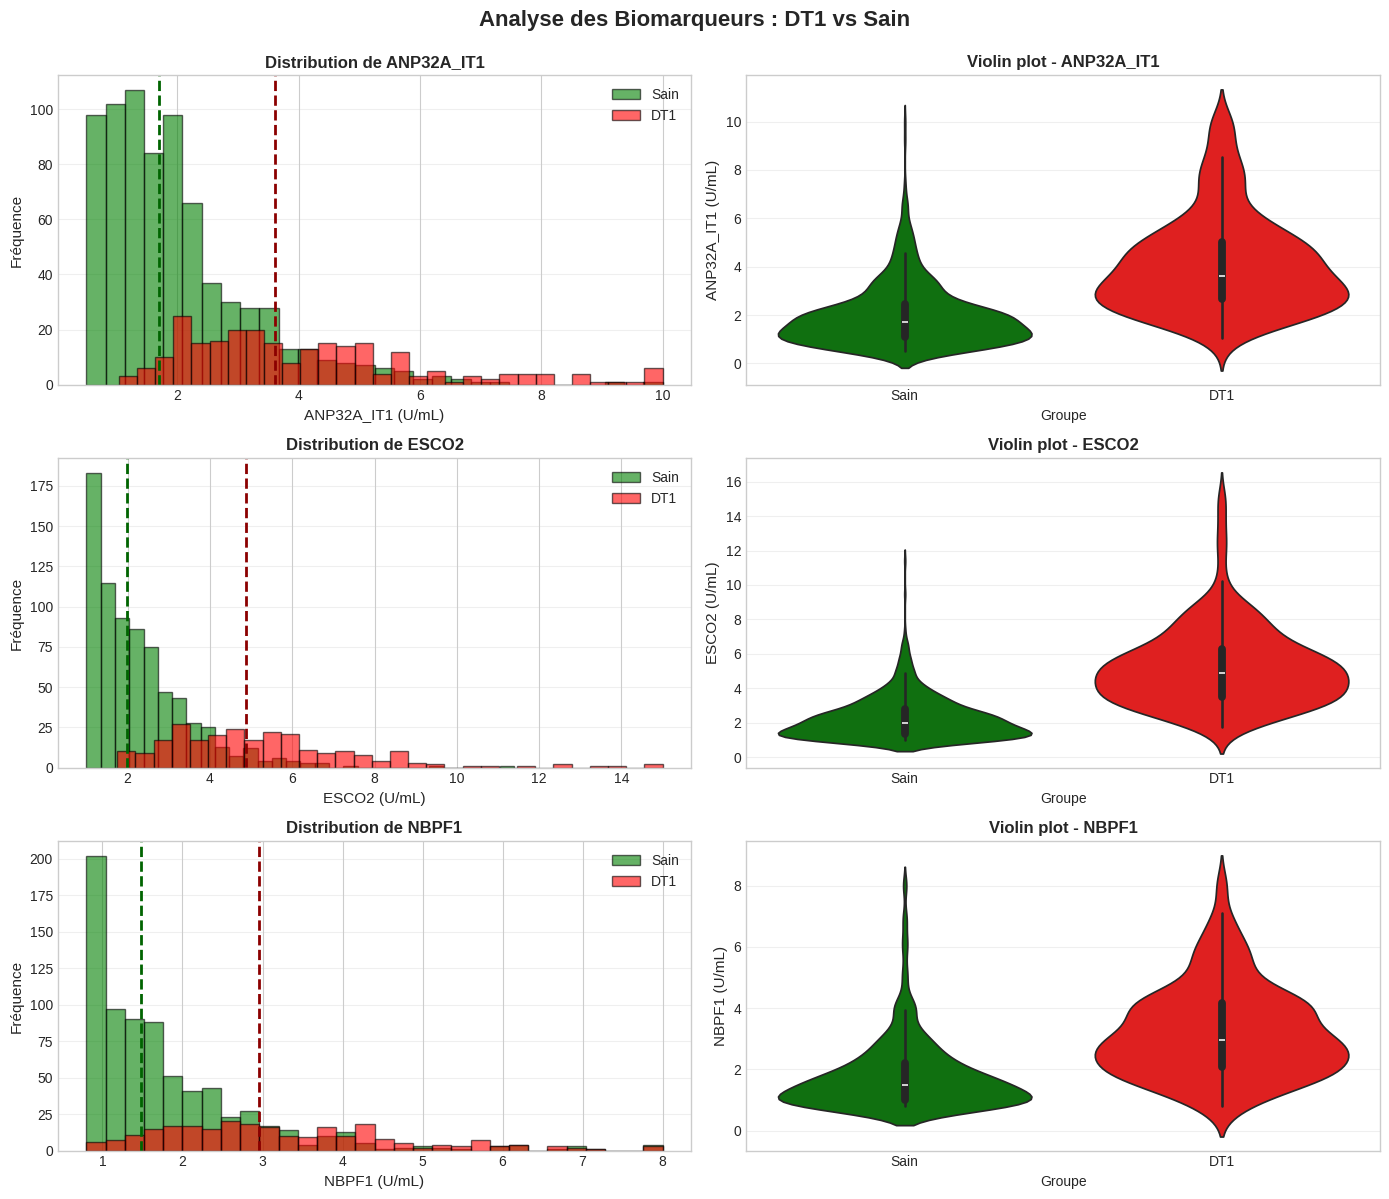


📊 Statistiques des biomarqueurs:

ANP32A_IT1:
   Médiane Sain: 1.70 U/mL
   Médiane DT1: 3.61 U/mL
   Différence: +112.2%

ESCO2:
   Médiane Sain: 1.98 U/mL
   Médiane DT1: 4.87 U/mL
   Différence: +146.0%

NBPF1:
   Médiane Sain: 1.48 U/mL
   Médiane DT1: 2.95 U/mL
   Différence: +99.2%


In [10]:
# === DISTRIBUTIONS DES BIOMARQUEURS ===

biomarqueurs = ['ANP32A_IT1', 'ESCO2', 'NBPF1']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, bio in enumerate(biomarqueurs):
    # Séparer les données
    sain = df[df['diagnostic'] == 0][bio]
    dt1 = df[df['diagnostic'] == 1][bio]
    
    # Colonne 1: Histogramme comparatif
    axes[i, 0].hist(sain, bins=30, alpha=0.6, label='Sain', color='green', edgecolor='black')
    axes[i, 0].hist(dt1, bins=30, alpha=0.6, label='DT1', color='red', edgecolor='black')
    axes[i, 0].set_xlabel(f'{bio} (U/mL)', fontsize=11)
    axes[i, 0].set_ylabel('Fréquence', fontsize=11)
    axes[i, 0].set_title(f'Distribution de {bio}', fontweight='bold')
    axes[i, 0].legend()
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Ajouter les médianes
    axes[i, 0].axvline(sain.median(), color='darkgreen', linestyle='--', linewidth=2, label='Médiane Sain')
    axes[i, 0].axvline(dt1.median(), color='darkred', linestyle='--', linewidth=2, label='Médiane DT1')
    
    # Colonne 2: Violin plot
    data_violin = pd.DataFrame({
        'Valeur': list(sain) + list(dt1),
        'Groupe': ['Sain']*len(sain) + ['DT1']*len(dt1)
    })
    sns.violinplot(data=data_violin, x='Groupe', y='Valeur', 
                   ax=axes[i, 1], palette={'Sain': 'green', 'DT1': 'red'})
    axes[i, 1].set_ylabel(f'{bio} (U/mL)', fontsize=11)
    axes[i, 1].set_title(f'Violin plot - {bio}', fontweight='bold')
    axes[i, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Analyse des Biomarqueurs : DT1 vs Sain', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📊 Statistiques des biomarqueurs:")
for bio in biomarqueurs:
    sain_median = df[df['diagnostic'] == 0][bio].median()
    dt1_median = df[df['diagnostic'] == 1][bio].median()
    diff_pct = ((dt1_median - sain_median) / sain_median) * 100
    
    print(f"\n{bio}:")
    print(f"   Médiane Sain: {sain_median:.2f} U/mL")
    print(f"   Médiane DT1: {dt1_median:.2f} U/mL")
    print(f"   Différence: {diff_pct:+.1f}%")

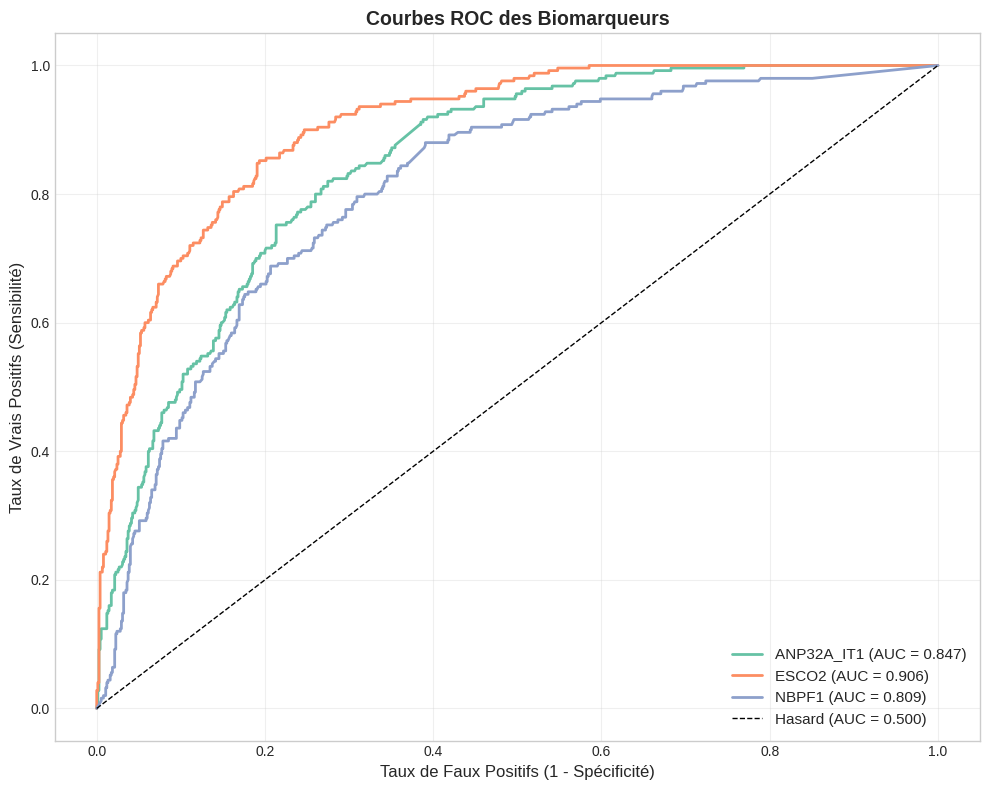


💡 Interprétation de l'AUC:
   AUC = 1.0 : Biomarqueur parfait
   AUC = 0.9-1.0 : Excellent
   AUC = 0.8-0.9 : Très bon
   AUC = 0.7-0.8 : Bon
   AUC = 0.5 : Pas mieux que le hasard


In [11]:
# === BIOMARQUEURS : COURBES ROC ===

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for bio in biomarqueurs:
    # Calculer la courbe ROC
    fpr, tpr, thresholds = roc_curve(df['diagnostic'], df[bio])
    roc_auc = auc(fpr, tpr)
    
    # Tracer la courbe
    plt.plot(fpr, tpr, linewidth=2, label=f'{bio} (AUC = {roc_auc:.3f})')

# Ligne de référence (classifier aléatoire)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC = 0.500)')

plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
plt.title('Courbes ROC des Biomarqueurs', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interprétation de l'AUC:")
print("   AUC = 1.0 : Biomarqueur parfait")
print("   AUC = 0.9-1.0 : Excellent")
print("   AUC = 0.8-0.9 : Très bon")
print("   AUC = 0.7-0.8 : Bon")
print("   AUC = 0.5 : Pas mieux que le hasard")

## 🔍 Partie 5 : Détection des Outliers

Identifier les valeurs aberrantes qui pourraient affecter les modèles.

In [12]:
# === DÉTECTION PAR MÉTHODE IQR ===

print("🔍 DÉTECTION DES OUTLIERS (méthode IQR)\n")
print("Méthode: Valeurs en dehors de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]\n")

outliers_summary = []

for var in variables_cles:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifier les outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outliers_summary.append({
        'Variable': var,
        'N_outliers': n_outliers,
        'Pourcentage': pct_outliers,
        'Borne_inf': lower_bound,
        'Borne_sup': upper_bound
    })
    
    print(f"{var:15} : {n_outliers:3d} outliers ({pct_outliers:4.1f}%) - Bornes: [{lower_bound:.2f}, {upper_bound:.2f}]")

df_outliers = pd.DataFrame(outliers_summary)

print("\n⚠️ Variables avec le plus d'outliers:")
top_outliers = df_outliers.nlargest(3, 'N_outliers')
for _, row in top_outliers.iterrows():
    print(f"   {row['Variable']}: {row['N_outliers']} ({row['Pourcentage']:.1f}%)")

🔍 DÉTECTION DES OUTLIERS (méthode IQR)

Méthode: Valeurs en dehors de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]

age             :   5 outliers ( 0.5%) - Bornes: [0.00, 64.00]
IMC             :   8 outliers ( 0.8%) - Bornes: [11.85, 36.26]
glycemie_jeun   : 166 outliers (16.6%) - Bornes: [1.70, 9.49]
HbA1c           : 183 outliers (18.3%) - Bornes: [3.20, 7.94]
ANP32A_IT1      :  40 outliers ( 4.0%) - Bornes: [-1.79, 6.32]
ESCO2           :  43 outliers ( 4.3%) - Bornes: [-1.87, 7.23]
NBPF1           :  44 outliers ( 4.4%) - Bornes: [-1.36, 5.24]

⚠️ Variables avec le plus d'outliers:
   HbA1c: 183 (18.3%)
   glycemie_jeun: 166 (16.6%)
   NBPF1: 44 (4.4%)


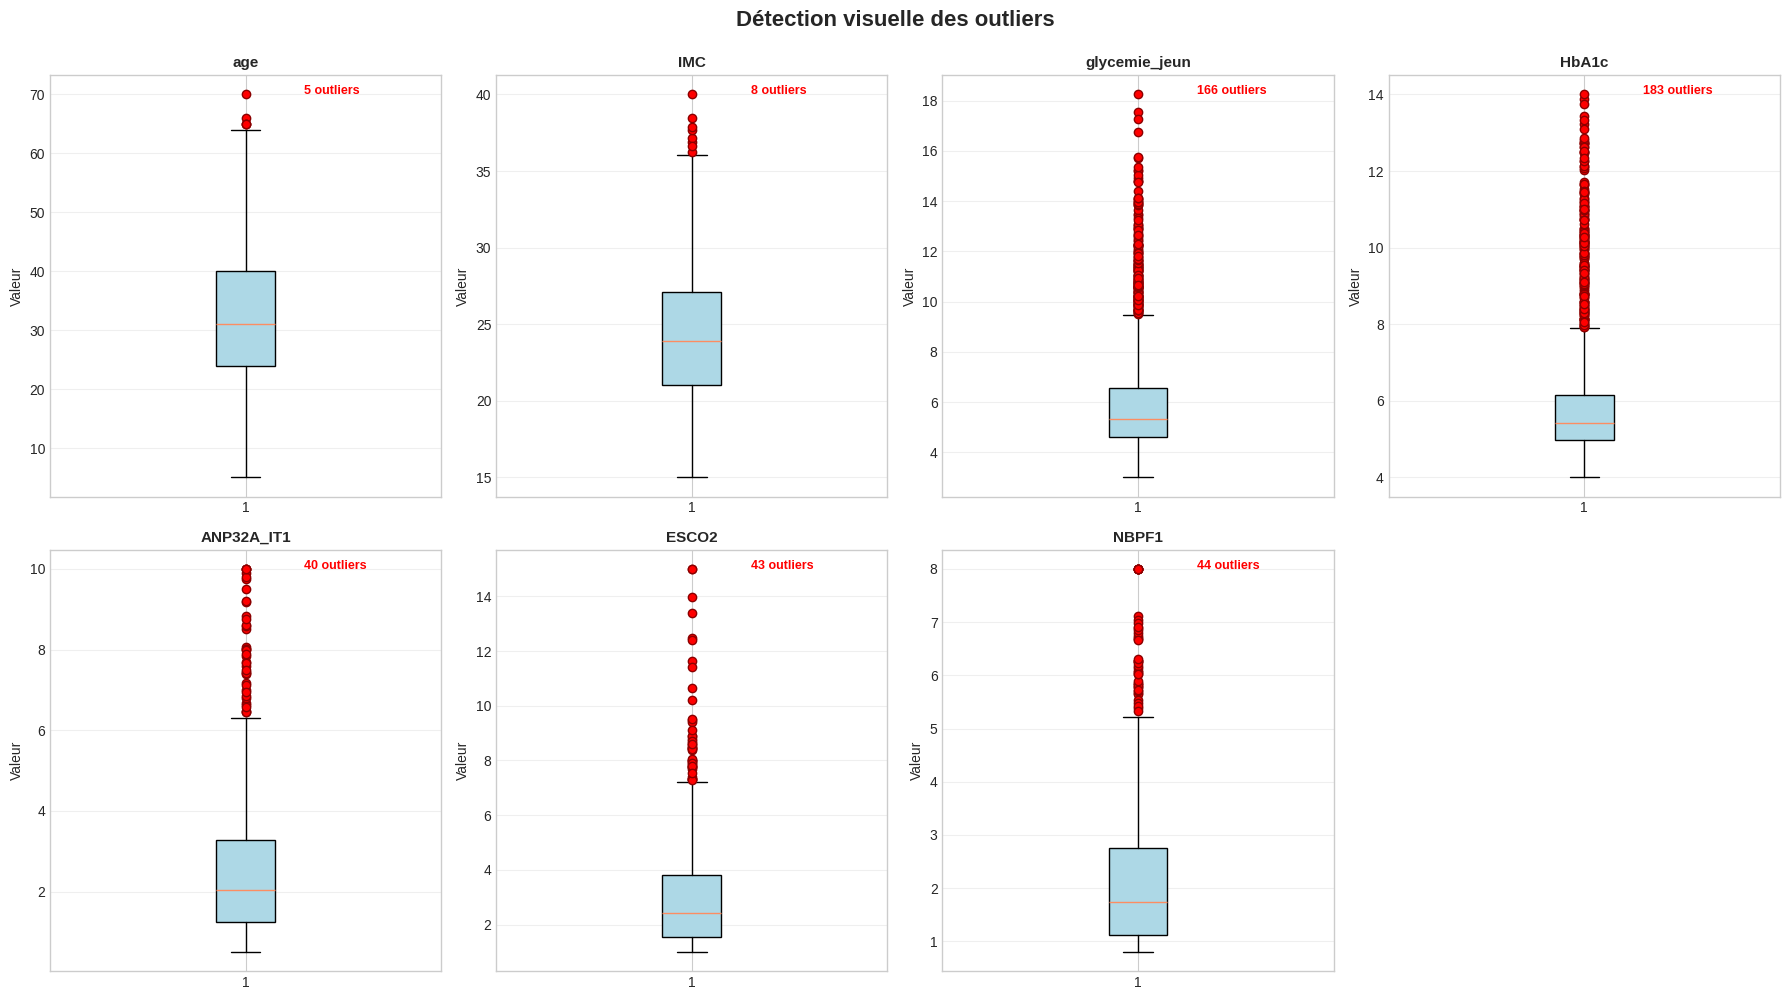


💡 Outliers en rouge dans les boxplots


In [13]:
# === VISUALISATION DES OUTLIERS ===

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_cles):
    # Créer un boxplot avec outliers en rouge
    bp = axes[i].boxplot(df[var], patch_artist=True, 
                         boxprops=dict(facecolor='lightblue'),
                         flierprops=dict(marker='o', markerfacecolor='red', 
                                        markersize=6, linestyle='none', 
                                        markeredgecolor='darkred'))
    axes[i].set_title(f'{var}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Valeur', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Ajouter le nombre d'outliers
    n_out = df_outliers[df_outliers['Variable'] == var]['N_outliers'].values[0]
    axes[i].text(1.15, df[var].max(), f'{n_out} outliers', 
                fontsize=9, color='red', fontweight='bold')

axes[7].axis('off')

plt.suptitle('Détection visuelle des outliers', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 Outliers en rouge dans les boxplots")

## ✏️ Exercices Pratiques

### Exercice 1 : Analyse de la glycémie

**Tâche:** 
1. Calculez le pourcentage de patients avec glycémie > 7 mmol/L dans chaque groupe (DT1 vs Sain)
2. Créez un graphique en barres comparatif

Patients avec glycémie > 7 mmol/L:
   Sain: 4/750 (0.5%)
   DT1: 225/250 (90.0%)


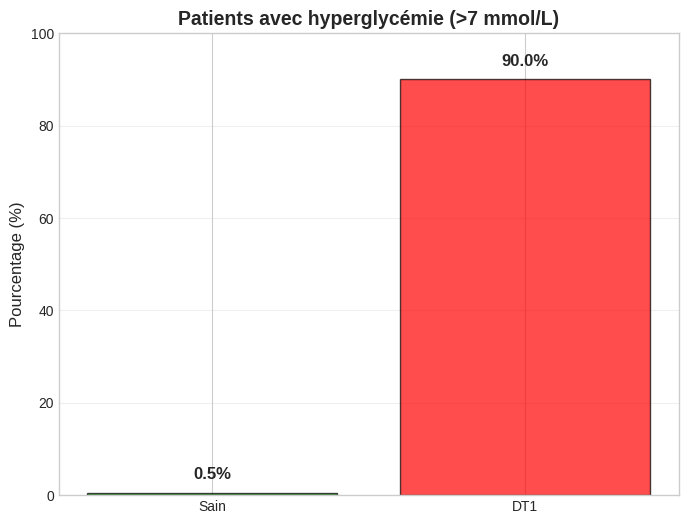

In [14]:
# VOTRE CODE ICI

# 1. Calcul des pourcentages
sain_hyper = (df[df['diagnostic'] == 0]['glycemie_jeun'] > 7).sum()
sain_total = (df['diagnostic'] == 0).sum()
pct_sain = (sain_hyper / sain_total) * 100

dt1_hyper = (df[df['diagnostic'] == 1]['glycemie_jeun'] > 7).sum()
dt1_total = (df['diagnostic'] == 1).sum()
pct_dt1 = (dt1_hyper / dt1_total) * 100

print(f"Patients avec glycémie > 7 mmol/L:")
print(f"   Sain: {sain_hyper}/{sain_total} ({pct_sain:.1f}%)")
print(f"   DT1: {dt1_hyper}/{dt1_total} ({pct_dt1:.1f}%)")

# 2. Visualisation
plt.figure(figsize=(8, 6))
plt.bar(['Sain', 'DT1'], [pct_sain, pct_dt1], 
        color=['green', 'red'], edgecolor='black', alpha=0.7)
plt.ylabel('Pourcentage (%)', fontsize=12)
plt.title('Patients avec hyperglycémie (>7 mmol/L)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
plt.text(0, pct_sain + 3, f'{pct_sain:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.text(1, pct_dt1 + 3, f'{pct_dt1:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.show()

### Exercice 2 : Corrélation entre biomarqueurs

**Tâche:** Identifiez quelle paire de biomarqueurs a la plus forte corrélation positive.

In [15]:
# VOTRE CODE ICI

# Matrice de corrélation des biomarqueurs uniquement
corr_bio = df[biomarqueurs].corr()

print("Matrice de corrélation des biomarqueurs:\n")
print(corr_bio.round(3))

# Extraire les corrélations hors diagonale
corr_ANP_ESCO = corr_bio.loc['ANP32A_IT1', 'ESCO2']
corr_ANP_NBPF = corr_bio.loc['ANP32A_IT1', 'NBPF1']
corr_ESCO_NBPF = corr_bio.loc['ESCO2', 'NBPF1']

print(f"\nCorrélations entre paires:")
print(f"   ANP32A-IT1 ↔ ESCO2: {corr_ANP_ESCO:.3f}")
print(f"   ANP32A-IT1 ↔ NBPF1: {corr_ANP_NBPF:.3f}")
print(f"   ESCO2 ↔ NBPF1: {corr_ESCO_NBPF:.3f}")

# Identifier la plus forte
correlations = {
    'ANP32A-IT1 ↔ ESCO2': corr_ANP_ESCO,
    'ANP32A-IT1 ↔ NBPF1': corr_ANP_NBPF,
    'ESCO2 ↔ NBPF1': corr_ESCO_NBPF
}
paire_max = max(correlations, key=correlations.get)
corr_max = correlations[paire_max]

print(f"\n✅ Corrélation la plus forte: {paire_max} (r = {corr_max:.3f})")

Matrice de corrélation des biomarqueurs:

            ANP32A_IT1  ESCO2  NBPF1
ANP32A_IT1       1.000  0.359  0.238
ESCO2            0.359  1.000  0.282
NBPF1            0.238  0.282  1.000

Corrélations entre paires:
   ANP32A-IT1 ↔ ESCO2: 0.359
   ANP32A-IT1 ↔ NBPF1: 0.238
   ESCO2 ↔ NBPF1: 0.282

✅ Corrélation la plus forte: ANP32A-IT1 ↔ ESCO2 (r = 0.359)


## 🎯 Auto-évaluation

### Questions de compréhension:

1. **Quelle est la différence entre médiane et moyenne?**
   - Moyenne: sensible aux outliers
   - Médiane: robuste aux outliers (valeur du milieu)

2. **Que signifie une p-value < 0.05?**
   - La différence observée est statistiquement significative
   - Probabilité < 5% que cette différence soit due au hasard

3. **Comment interpréter une AUC de 0.85 pour un biomarqueur?**
   - Excellent pouvoir discriminant DT1 vs Sain
   - 85% de chances de bien classer un patient aléatoire

4. **Pourquoi faut-il détecter les outliers?**
   - Peuvent biaiser les modèles
   - Peuvent indiquer des erreurs de mesure
   - Décision à prendre: conserver, transformer ou supprimer

### Points clés à retenir:

✅ Toujours comparer les distributions DT1 vs Sain  
✅ Utiliser des tests statistiques pour valider les différences observées  
✅ Analyser les corrélations pour éviter la redondance de features  
✅ Les biomarqueurs ESCO2, ANP32A-IT1, NBPF1 sont discriminants  
✅ Les outliers nécessitent une attention particulière  

---

## 🎉 Félicitations!

Vous avez complété l'analyse exploratoire des données. Vous êtes maintenant prêt(e) pour la modélisation!

### 📅 Prochaine étape:
**Semaine 3:** Modélisation simple avec algorithmes de base (Logistic Regression, Decision Tree, Random Forest)

---

*Notebook créé pour le projet DT1 Cameroun - Master 2 Biophysique - 2025*